# <center><b>Car Price Prediction</b></center>

In [1]:
#import libraies
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
#read data
df = pd.read_csv("cars_data.csv")
df.head()

,Brand,Year,Mileage,Engine_Size,Fuel_Type,Transmission,Previous_Owners,Price
0,Kia,2015.0,110373.0,2.5,Electric,Manual,2,3000.0
1,Mercedes,2010.0,186144.0,1.3,Electric,Manual,5,4844.0
2,Nissan,2018.0,29574.0,2.6,Petrol,Manual,1,6628.0
3,Kia,2010.0,139502.0,2.4,Diesel,Automatic,NaN,3000.0
4,BMW,2014.0,148748.0,3.5,Diesel,Manual,1,6451.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            979 non-null    object 
 1   Year             974 non-null    float64
 2   Mileage          979 non-null    float64
 3   Engine_Size      964 non-null    float64
 4   Fuel_Type        982 non-null    object 
 5   Transmission     962 non-null    object 
 6   Previous_Owners  950 non-null    object 
 7   Price            987 non-null    float64
dtypes: float64(4), object(4)
memory usage: 62.6+ KB


In [4]:
#shape of data
df.shape

(1000, 8)

In [5]:
#coping data for any mistake occured
df_copy = df

In [6]:
#fill NANs 
for i in df_copy.columns:
    df_copy[i] = df_copy[i].fillna(df_copy[i].mode()[0])

In [7]:
df_copy["Mileage"] = df_copy["Mileage"].fillna(df_copy["Mileage"].mean())

In [8]:
df_copy.isna().sum().sum()

np.int64(0)

In [9]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            1000 non-null   object 
 1   Year             1000 non-null   float64
 2   Mileage          1000 non-null   float64
 3   Engine_Size      1000 non-null   float64
 4   Fuel_Type        1000 non-null   object 
 5   Transmission     1000 non-null   object 
 6   Previous_Owners  1000 non-null   object 
 7   Price            1000 non-null   float64
dtypes: float64(4), object(4)
memory usage: 62.6+ KB


In [10]:
#showing # of unique values in featuers 
for i in df_copy:
    print(i,"# Uniques:",df_copy[i].nunique())

Brand # Uniques: 8
Year # Uniques: 14
Mileage # Uniques: 978
Engine_Size # Uniques: 31
Fuel_Type # Uniques: 4
Transmission # Uniques: 2
Previous_Owners # Uniques: 6
Price # Uniques: 831


In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
#label encoding for categorical columns
le = LabelEncoder()
categorical_featuers = df_copy.select_dtypes(include="object")
for i in categorical_featuers:
    df_copy[i] = le.fit_transform(df_copy[i])

In [13]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            1000 non-null   int64  
 1   Year             1000 non-null   float64
 2   Mileage          1000 non-null   float64
 3   Engine_Size      1000 non-null   float64
 4   Fuel_Type        1000 non-null   int64  
 5   Transmission     1000 non-null   int64  
 6   Previous_Owners  1000 non-null   int64  
 7   Price            1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


In [14]:
df_copy.head(10)

,Brand,Year,Mileage,Engine_Size,Fuel_Type,Transmission,Previous_Owners,Price
0,3,2015.0,110373.0,2.5,1,1,2,3000.0
1,5,2010.0,186144.0,1.3,1,1,5,4844.0
2,6,2018.0,29574.0,2.6,3,1,1,6628.0
3,3,2010.0,139502.0,2.4,0,0,5,3000.0
4,0,2014.0,148748.0,3.5,0,1,1,6451.0
5,4,2013.0,146888.0,1.3,0,1,5,3000.0
6,6,2022.0,37733.0,2.5,3,1,5,8810.0
7,6,2021.0,7050.0,1.5,0,0,5,10365.0
8,3,2022.0,114996.0,2.0,3,1,1,4987.0
9,1,2022.0,38933.0,3.2,2,1,5,21380.0


In [15]:
#duplicated rows 
df_copy.duplicated().sum()

np.int64(0)

<Axes: >

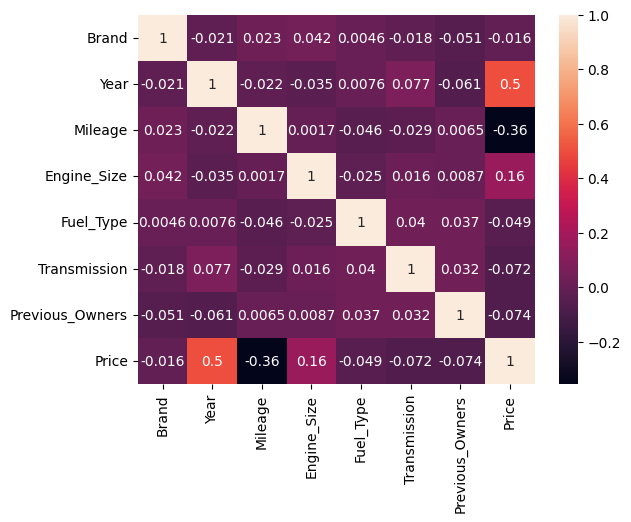

In [16]:
#drawwing of relationships between featuers & each others
correlation = df_copy.corr(numeric_only=True)
sns.heatmap(correlation, annot=True)

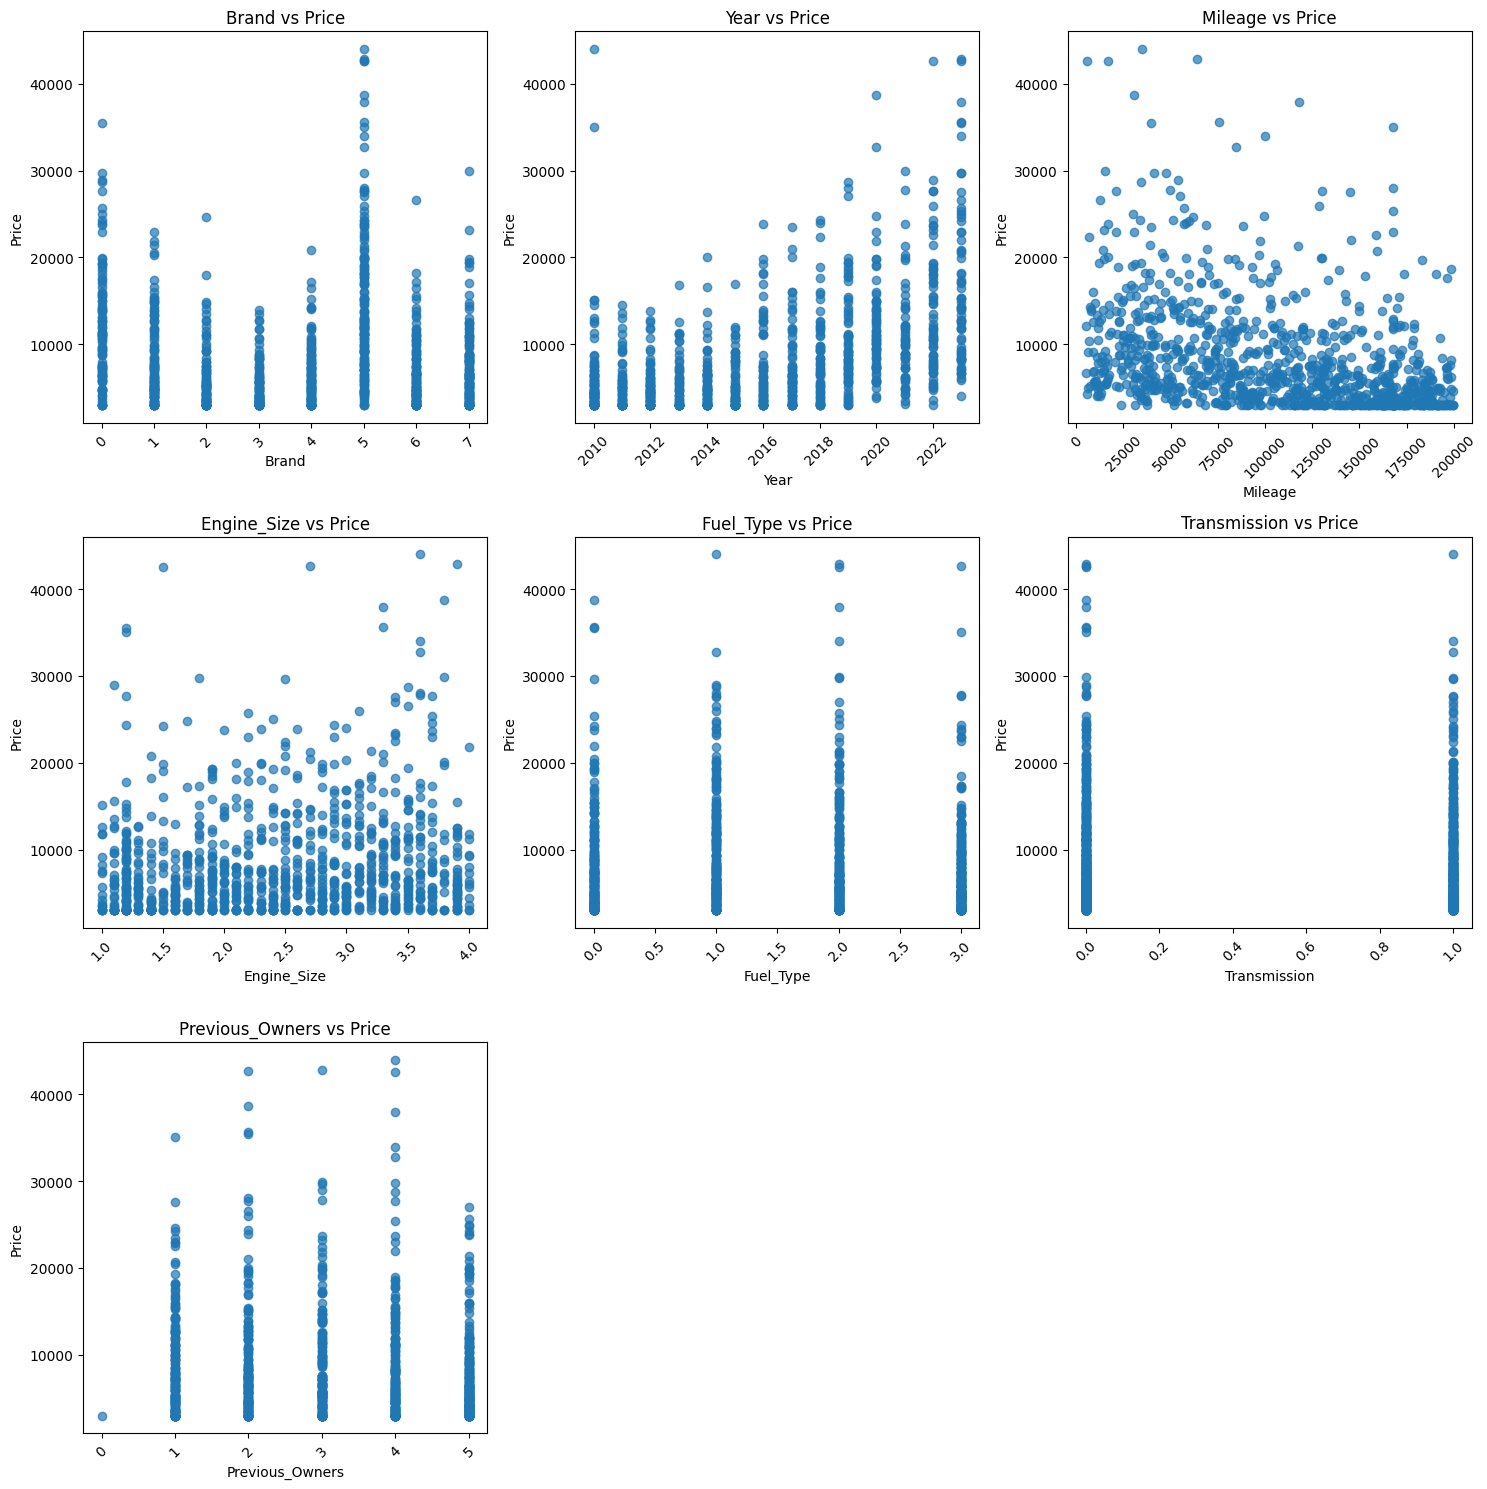

In [17]:
#subplots to decide if outliers exists or not 
x_cols = df_copy.drop("Price",axis=1)
plt.figure(figsize=(15, 15))

for i, col in enumerate(x_cols):
    if i < 9:
        plt.subplot(3, 3,i+1)
        plt.scatter(df_copy[col], df_copy["Price"], alpha=0.7)
        plt.title(f"{col} vs Price")
        plt.xlabel(col)
        plt.ylabel("Price")
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
#data splitting into train and test
X = df_copy.drop("Price",axis=1)
y = df["Price"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2,shuffle=True)

In [19]:
#normalization to make mean = 0 and std = 1
from sklearn.preprocessing import MinMaxScaler
MM = MinMaxScaler()

X_train_scaled = MM.fit_transform(X_train)
X_test_scaled = MM.transform(X_test)

print("Shape of Train data :",X_train_scaled.shape)
print("Shape of Test data :",X_test_scaled.shape)

Shape of Train data : (800, 7)
Shape of Test data : (200, 7)


In [20]:
X_test_scaled

array([[0.42857143, 0.76923077, 0.81329454, ..., 1.        , 0.        ,
        0.6       ],
       [0.85714286, 0.38461538, 0.41253579, ..., 1.        , 0.        ,
        0.4       ],
       [0.42857143, 0.        , 0.39556677, ..., 0.        , 1.        ,
        1.        ],
       ...,
       [0.28571429, 0.        , 0.63488596, ..., 1.        , 0.        ,
        0.4       ],
       [0.14285714, 0.84615385, 0.47013072, ..., 0.33333333, 0.        ,
        0.6       ],
       [0.42857143, 0.07692308, 0.42676489, ..., 0.33333333, 1.        ,
        0.6       ]])

In [21]:
#import models
from sklearn.neighbors import KNeighborsRegressor

In [64]:
#prepare it
k_n_n = KNeighborsRegressor(n_neighbors=3,p=1,metric="minkowski")

In [65]:
#data trainning
k_n_n.fit(X_train_scaled,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [66]:
#data prediction on test data
y_pred = k_n_n.predict(X_test_scaled)

In [67]:
#evaluatation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

print("Mean Square Error On test data is:",mean_squared_error(y_test,y_pred))
print("Root Mean Square Error is :",root_mean_squared_error(y_test,y_pred))
print("Mean Absolute Error On test data is:",mean_absolute_error(y_test,y_pred))
print("R2_Score is :",r2_score(y_test,y_pred))
print("\n")

Mean Square Error On test data is: 20703439.814999998
Root Mean Square Error is : 4550.1032752015635
Mean Absolute Error On test data is: 2784.241666666667
R2_Score is : 0.49015560542176206




# <center><b>Thank You</b></center>